In [ ]:
# 1. SETUP
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np
import random

manual_seed = 999
random.seed(manual_seed)
torch.manual_seed(manual_seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Using device: cuda:0
GPU: Tesla T4


In [ ]:
# 2. HYPERPARAMETERS
dataroot = "./data"
workers = 2
batch_size = 128
image_size = 32
nc = 1
nz = 100
ngf = 64
ndf = 64
num_epochs = 50
lr = 0.0002
beta1 = 0.5

In [ ]:
# 3. LOAD FASHION-MNIST DATASET
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Single channel
])

dataset = torchvision.datasets.FashionMNIST(
    root=dataroot,
    train=True,
    download=True,
    transform=transform
)

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=workers
)

print(f"Dataset size: {len(dataset)} images")
print(f"Image shape: {dataset[0][0].shape}")

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 306kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.59MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.6MB/s]

Dataset size: 60000 images
Image shape: torch.Size([1, 32, 32])


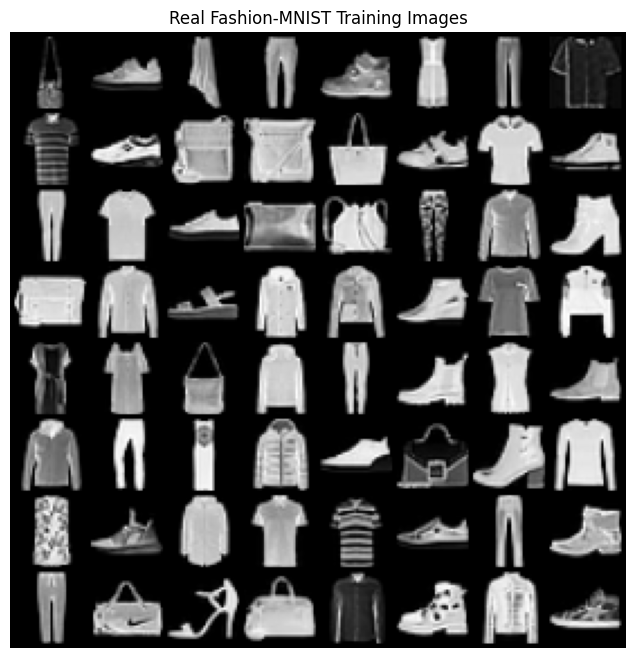

In [ ]:
# 4. VISUALIZE REAL TRAINING IMAGES
real_batch = next(iter(dataloader))
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Real Fashion-MNIST Training Images")
plt.imshow(
    np.transpose(
        vutils.make_grid(real_batch[0][:64], padding=2, normalize=True).cpu(),
        (1, 2, 0)
    ),
    cmap="gray"
)
plt.show()

In [ ]:
# 5. WEIGHT INITIALIZATION (unchanged from original tutorial)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [ ]:
# 6. GENERATOR
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # nz x 1 x 1 -> (ngf*4) x 4 x 4
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # (ngf*4) x 4 x 4 -> (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # (ngf*2) x 8 x 8 -> ngf x 16 x 16
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # ngf x 16 x 16 -> nc x 32 x 32
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

In [ ]:
# 7. DISCRIMINATOR
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # nc x 32 x 32 -> ndf x 16 x 16
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # ndf x 16 x 16 -> (ndf*2) x 8 x 8
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2) x 8 x 8 -> (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4) x 4 x 4 -> 1 x 1 x 1
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4)

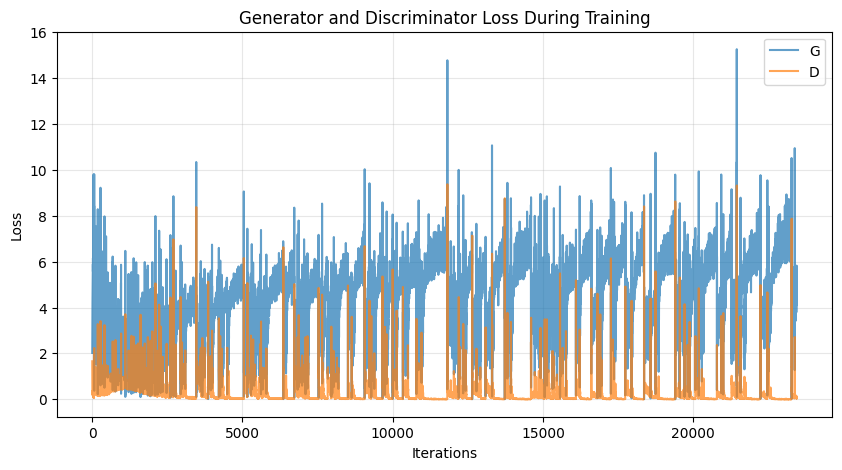

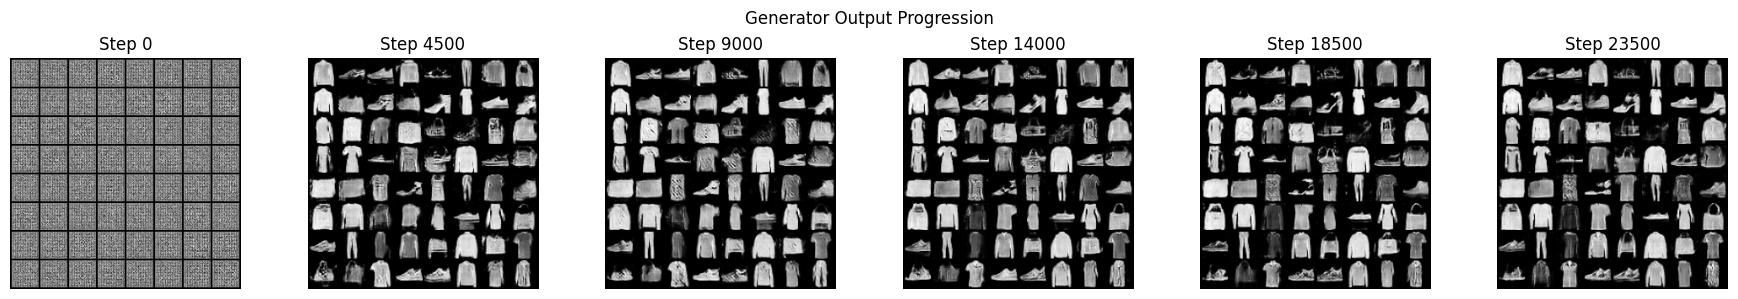

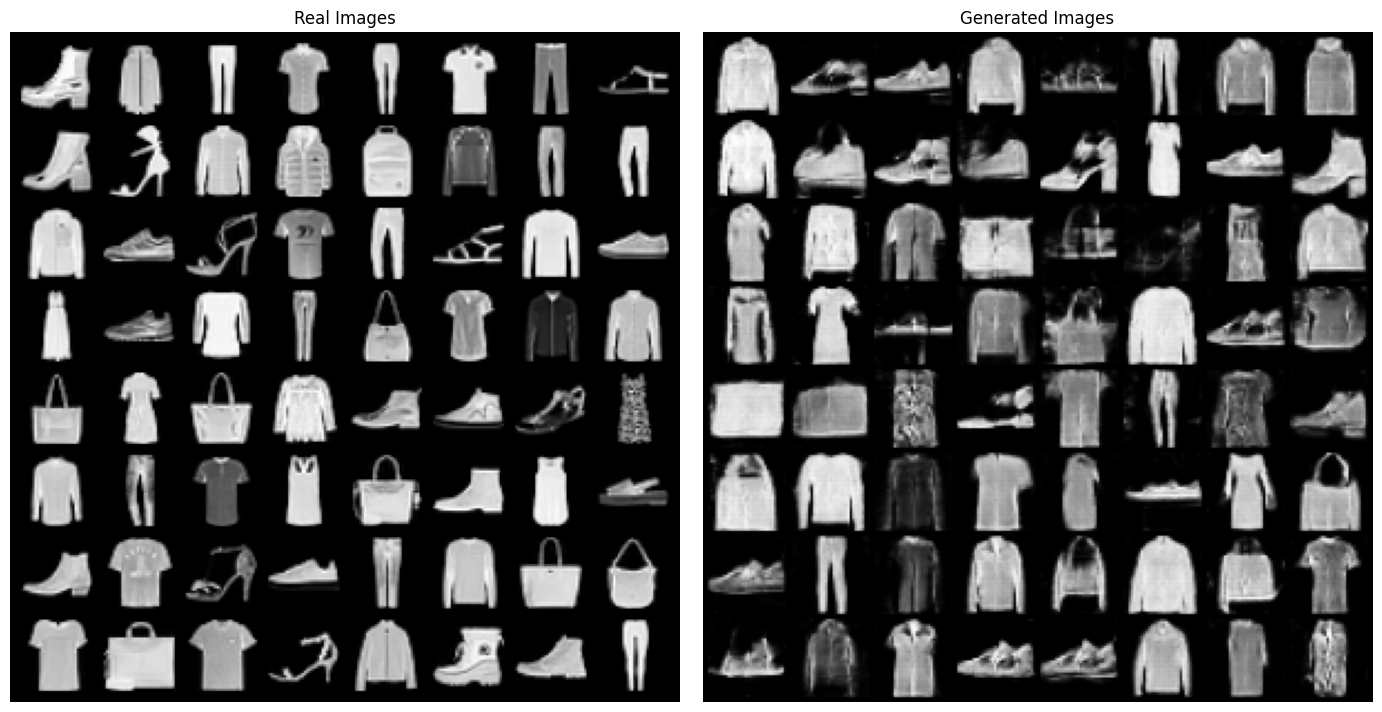

Simplified FID Score: 29.66
(Lower is better. Uses pixel space, not Inception features.)
Models saved.


/tmp/ipykernel_1184/1515475751.py:140: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma_real @ sigma_fake)


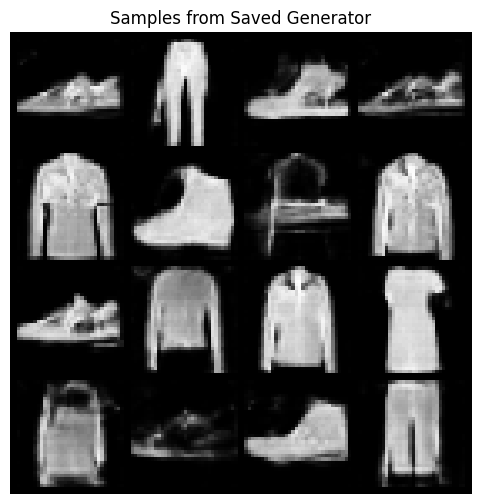

In [ ]:
# 8. CREATE MODELS
netG = Generator().to(device)
netG.apply(weights_init)
print(netG)

netD = Discriminator().to(device)
netD.apply(weights_init)
print(netD)

# Verify shapes
test_noise = torch.randn(1, nz, 1, 1, device=device)
test_out_g = netG(test_noise)
test_out_d = netD(test_out_g)
print(f"\nGenerator output: {test_out_g.shape}")     # [1, 1, 32, 32]
print(f"Discriminator output: {test_out_d.shape}")   # [1, 1, 1, 1]

# 9. LOSS AND OPTIMIZERS (unchanged from original)
criterion = nn.BCELoss()
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
real_label = 1.0
fake_label = 0.0
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

# 10. TRAINING LOOP (structurally unchanged from original)
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
print(f"Epochs: {num_epochs} | Batch size: {batch_size} | Image size: {image_size}x{image_size}")
print("-" * 60)

for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):

        # --- Train Discriminator ---
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        # --- Train Generator ---
        netG.zero_grad()
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        if i % 100 == 0:
            print(
                f"[{epoch:3d}/{num_epochs}][{i:3d}/{len(dataloader)}]  "
                f"Loss_D: {errD.item():.4f}  Loss_G: {errG.item():.4f}  "
                f"D(x): {D_x:.4f}  D(G(z)): {D_G_z1:.4f} / {D_G_z2:.4f}"
            )

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if (iters % 500 == 0) or ((epoch == num_epochs - 1) and (i == len(dataloader) - 1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

print("\nTraining complete!")

# 11. PLOT TRAINING LOSSES
plt.figure(figsize=(10, 5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G", alpha=0.7)
plt.plot(D_losses, label="D", alpha=0.7)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 12. GENERATOR PROGRESSION
fig, axes = plt.subplots(1, min(len(img_list), 6), figsize=(18, 3))
indices = np.linspace(0, len(img_list) - 1, min(len(img_list), 6), dtype=int)
for ax, idx in zip(axes, indices):
    ax.imshow(np.transpose(img_list[idx], (1, 2, 0)), cmap="gray")
    ax.set_title(f"Step {idx * 500}")
    ax.axis("off")
plt.suptitle("Generator Output Progression")
plt.tight_layout()
plt.show()

# 13. REAL vs GENERATED COMPARISON
real_batch = next(iter(dataloader))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

ax1.set_title("Real Images")
ax1.imshow(
    np.transpose(vutils.make_grid(real_batch[0][:64], padding=5, normalize=True).cpu(), (1, 2, 0)),
    cmap="gray"
)
ax1.axis("off")

ax2.set_title("Generated Images")
ax2.imshow(np.transpose(img_list[-1], (1, 2, 0)), cmap="gray")
ax2.axis("off")

plt.tight_layout()
plt.show()

# 14. SIMPLIFIED FID SCORE
from scipy import linalg

def calculate_fid_simple(real_images, fake_images):
    """Simplified FID using pixel statistics (not Inception features)."""
    real_flat = real_images.view(real_images.size(0), -1).numpy()
    fake_flat = fake_images.view(fake_images.size(0), -1).numpy()

    mu_real = real_flat.mean(axis=0)
    sigma_real = np.cov(real_flat, rowvar=False)
    mu_fake = fake_flat.mean(axis=0)
    sigma_fake = np.cov(fake_flat, rowvar=False)

    diff = mu_real - mu_fake
    covmean = linalg.sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

with torch.no_grad():
    gen_noise = torch.randn(500, nz, 1, 1, device=device)
    generated = netG(gen_noise).cpu()

real_imgs = []
for batch in dataloader:
    real_imgs.append(batch[0])
    if sum(r.size(0) for r in real_imgs) >= 500:
        break
real_imgs = torch.cat(real_imgs, dim=0)[:500]

fid_score = calculate_fid_simple(real_imgs, generated)
print(f"Simplified FID Score: {fid_score:.2f}")
print("(Lower is better. Uses pixel space, not Inception features.)")

# 15. SAVE MODELS
torch.save(netG.state_dict(), "generator_fashion_mnist.pth")
torch.save(netD.state_dict(), "discriminator_fashion_mnist.pth")
print("Models saved.")

# Quick test: load and generate
loaded_G = Generator().to(device)
loaded_G.load_state_dict(torch.load("generator_fashion_mnist.pth"))
loaded_G.eval()

with torch.no_grad():
    sample_noise = torch.randn(16, nz, 1, 1, device=device)
    samples = loaded_G(sample_noise).cpu()

plt.figure(figsize=(6, 6))
plt.imshow(
    np.transpose(vutils.make_grid(samples, nrow=4, padding=2, normalize=True), (1, 2, 0)),
    cmap="gray"
)
plt.title("Samples from Saved Generator")
plt.axis("off")
plt.show()